# Transfer Diagnose


In [2]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

ROOT_CANDIDATES = [Path.cwd(), Path.cwd().parent]
REPO_ROOT = next((path for path in ROOT_CANDIDATES if (path / "results").exists() and (path / "Visualization").exists()), Path.cwd())
RESULT_CACHE_ROOT = REPO_ROOT / "results"
FIGURE_DIR = REPO_ROOT / "Visualization" / "Graph"
FIGURE_DIR.mkdir(parents=True, exist_ok=True)

transfer_diagnose_cache_dir = RESULT_CACHE_ROOT / "major" / "transfer_diagnose"

transfer_diagnose_epoch_df = pd.read_csv(transfer_diagnose_cache_dir / "epoch_df.csv")
transfer_diagnose_epoch_summary_df = pd.read_csv(transfer_diagnose_cache_dir / "epoch_summary_df.csv")
transfer_diagnose_final_metric_df = pd.read_csv(transfer_diagnose_cache_dir / "final_metric_df.csv")
transfer_diagnose_final_summary_df = pd.read_csv(transfer_diagnose_cache_dir / "final_summary_df.csv")
transfer_diagnose_shift_df = pd.read_csv(transfer_diagnose_cache_dir / "shift_df.csv")


## CCVNet-Transfer Finetune Loss Diagnose


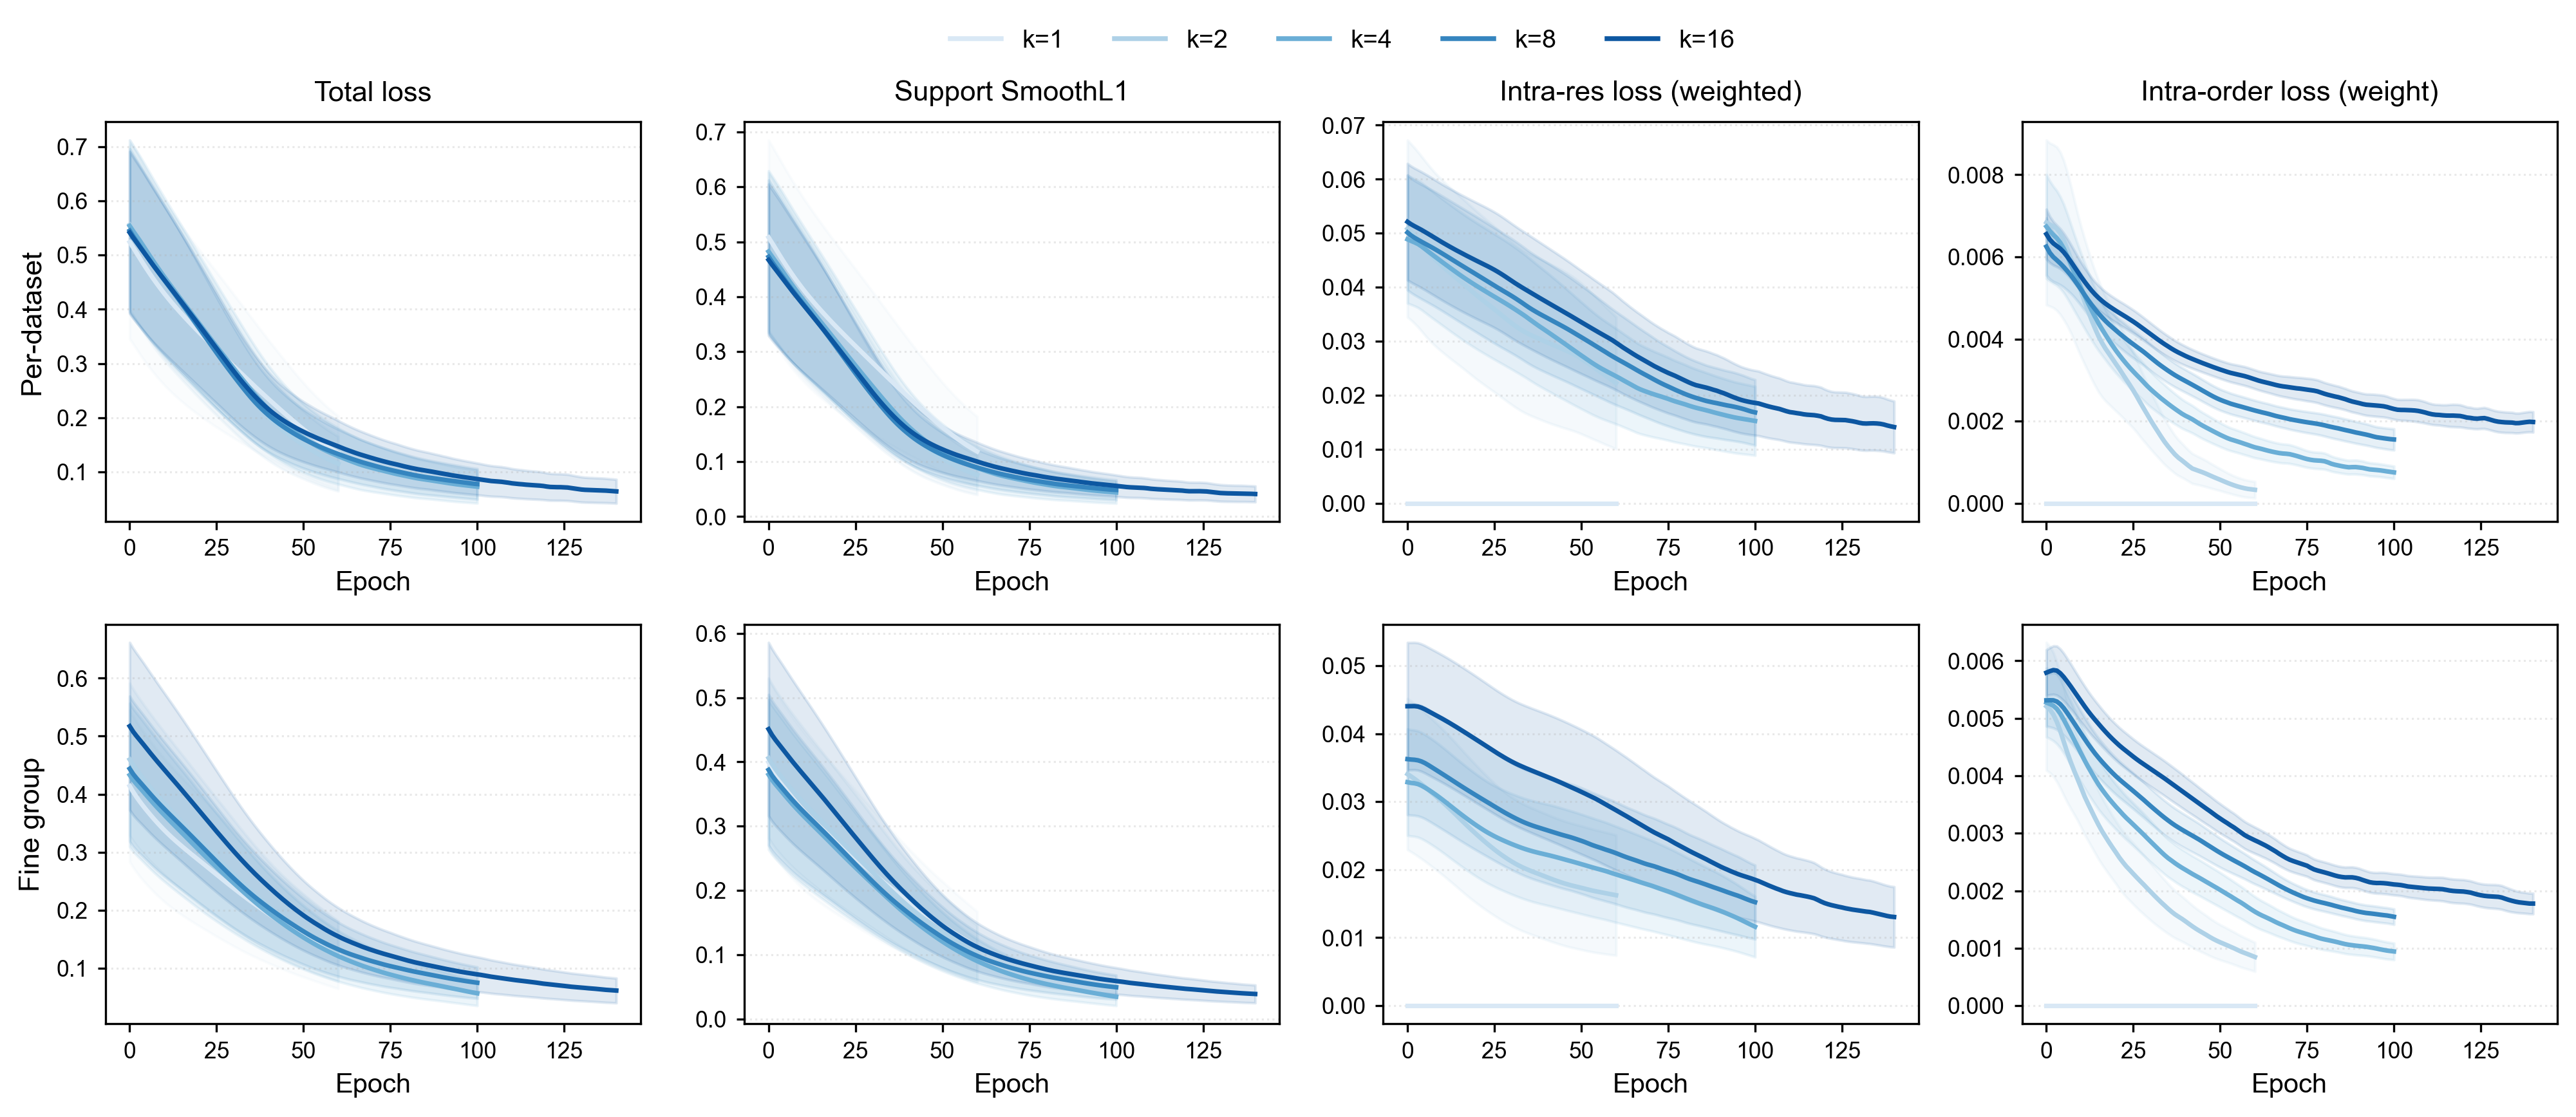

In [ ]:
plt.rcParams.update({
    "text.usetex": False,
    "font.family": "sans-serif",
    "font.sans-serif": ["Helvetica", "Arial", "DejaVu Sans"]
})

if ('transfer_diagnose_epoch_df' not in globals()) or transfer_diagnose_epoch_df.empty:
    print("Transfer diagnose support-loss trajectory is empty.")
else:
    plot_df = transfer_diagnose_epoch_df.copy()
    grouping_order = [name for name in ["by dataset", "fine subgroup"] if name in plot_df["grouping_scheme"].astype(str).unique().tolist()]
    k_order = [k for k in [1, 2, 4, 8, 16] if k in pd.to_numeric(plot_df["k_shot"], errors="coerce").dropna().astype(int).unique().tolist()]
    title_map = {
        "support_loss_total": "Total loss",
        "support_loss_abs": "Support SmoothL1",
        "support_loss_delta": "Intra-res loss (weighted)",
        "support_loss_rank": "Intra-order loss (weight)",
    }
    metric_order = list(title_map.keys())
    row_label_map = {"by dataset": "Per-dataset", "fine subgroup": "Fine group"}
    color_values = np.linspace(0.15, 0.85, max(len(k_order), 2))
    color_map = {int(k): plt.cm.Blues(color_values[idx]) for idx, k in enumerate(k_order)}

    fig, axes = plt.subplots(2, 4, figsize=(14.0, 5.8), dpi=300, squeeze=False)
    for row_idx, grouping_scheme in enumerate(grouping_order):
        for col_idx, metric_name in enumerate(metric_order):
            ax = axes[row_idx, col_idx]
            sub = plot_df.loc[plot_df["grouping_scheme"].eq(grouping_scheme)].copy()
            if sub.empty:
                ax.set_axis_off()
                continue
            for k_shot in k_order:
                k_sub = sub.loc[pd.to_numeric(sub["k_shot"], errors="coerce").eq(int(k_shot))].copy()
                if k_sub.empty:
                    continue
                grp = (
                    k_sub.groupby("epoch", dropna=False)[metric_name]
                    .agg(["mean", "std", "count"])
                    .reset_index()
                    .sort_values("epoch")
                )
                x = pd.to_numeric(grp["epoch"], errors="coerce").to_numpy(dtype=float)
                y = pd.to_numeric(grp["mean"], errors="coerce").to_numpy(dtype=float)
                std = pd.to_numeric(grp["std"], errors="coerce").fillna(0.0).to_numpy(dtype=float)
                count = pd.to_numeric(grp["count"], errors="coerce").fillna(0.0).to_numpy(dtype=float)
                ci95 = np.where(count > 1, 1.96 * std / np.sqrt(count), 0.0)
                ax.plot(x, y, color=color_map[int(k_shot)], linewidth=1.7, label=f"k={int(k_shot)}")
                ax.fill_between(x, y - ci95, y + ci95, color=color_map[int(k_shot)], alpha=0.12)
            if row_idx == 0:
                ax.set_title(title_map[metric_name], fontsize=10.5, pad=8)
            ax.set_xlabel("Epoch", fontsize=10)
            if col_idx == 0:
                ax.set_ylabel(row_label_map.get(grouping_scheme, grouping_scheme.title()), fontsize=10.5)
            else:
                ax.set_ylabel("")
            ax.grid(axis="y", linestyle=":", linewidth=0.75, alpha=0.28)
            ax.tick_params(labelsize=8.5, length=3)

    handles = [plt.Line2D([0], [0], color=color_map[int(k)], linewidth=1.8) for k in k_order]
    labels = [f"k={int(k)}" for k in k_order]
    fig.legend(handles, labels, frameon=False, fontsize=9.5, loc="upper center", bbox_to_anchor=(0.52, 1.02), ncol=len(k_order))
    fig.tight_layout(rect=[0.02, 0.02, 0.98, 0.98])
    #plt.savefig(FIGURE_DIR / "S10-13.tiff", format="tiff", dpi=500, bbox_inches="tight")
    plt.show()


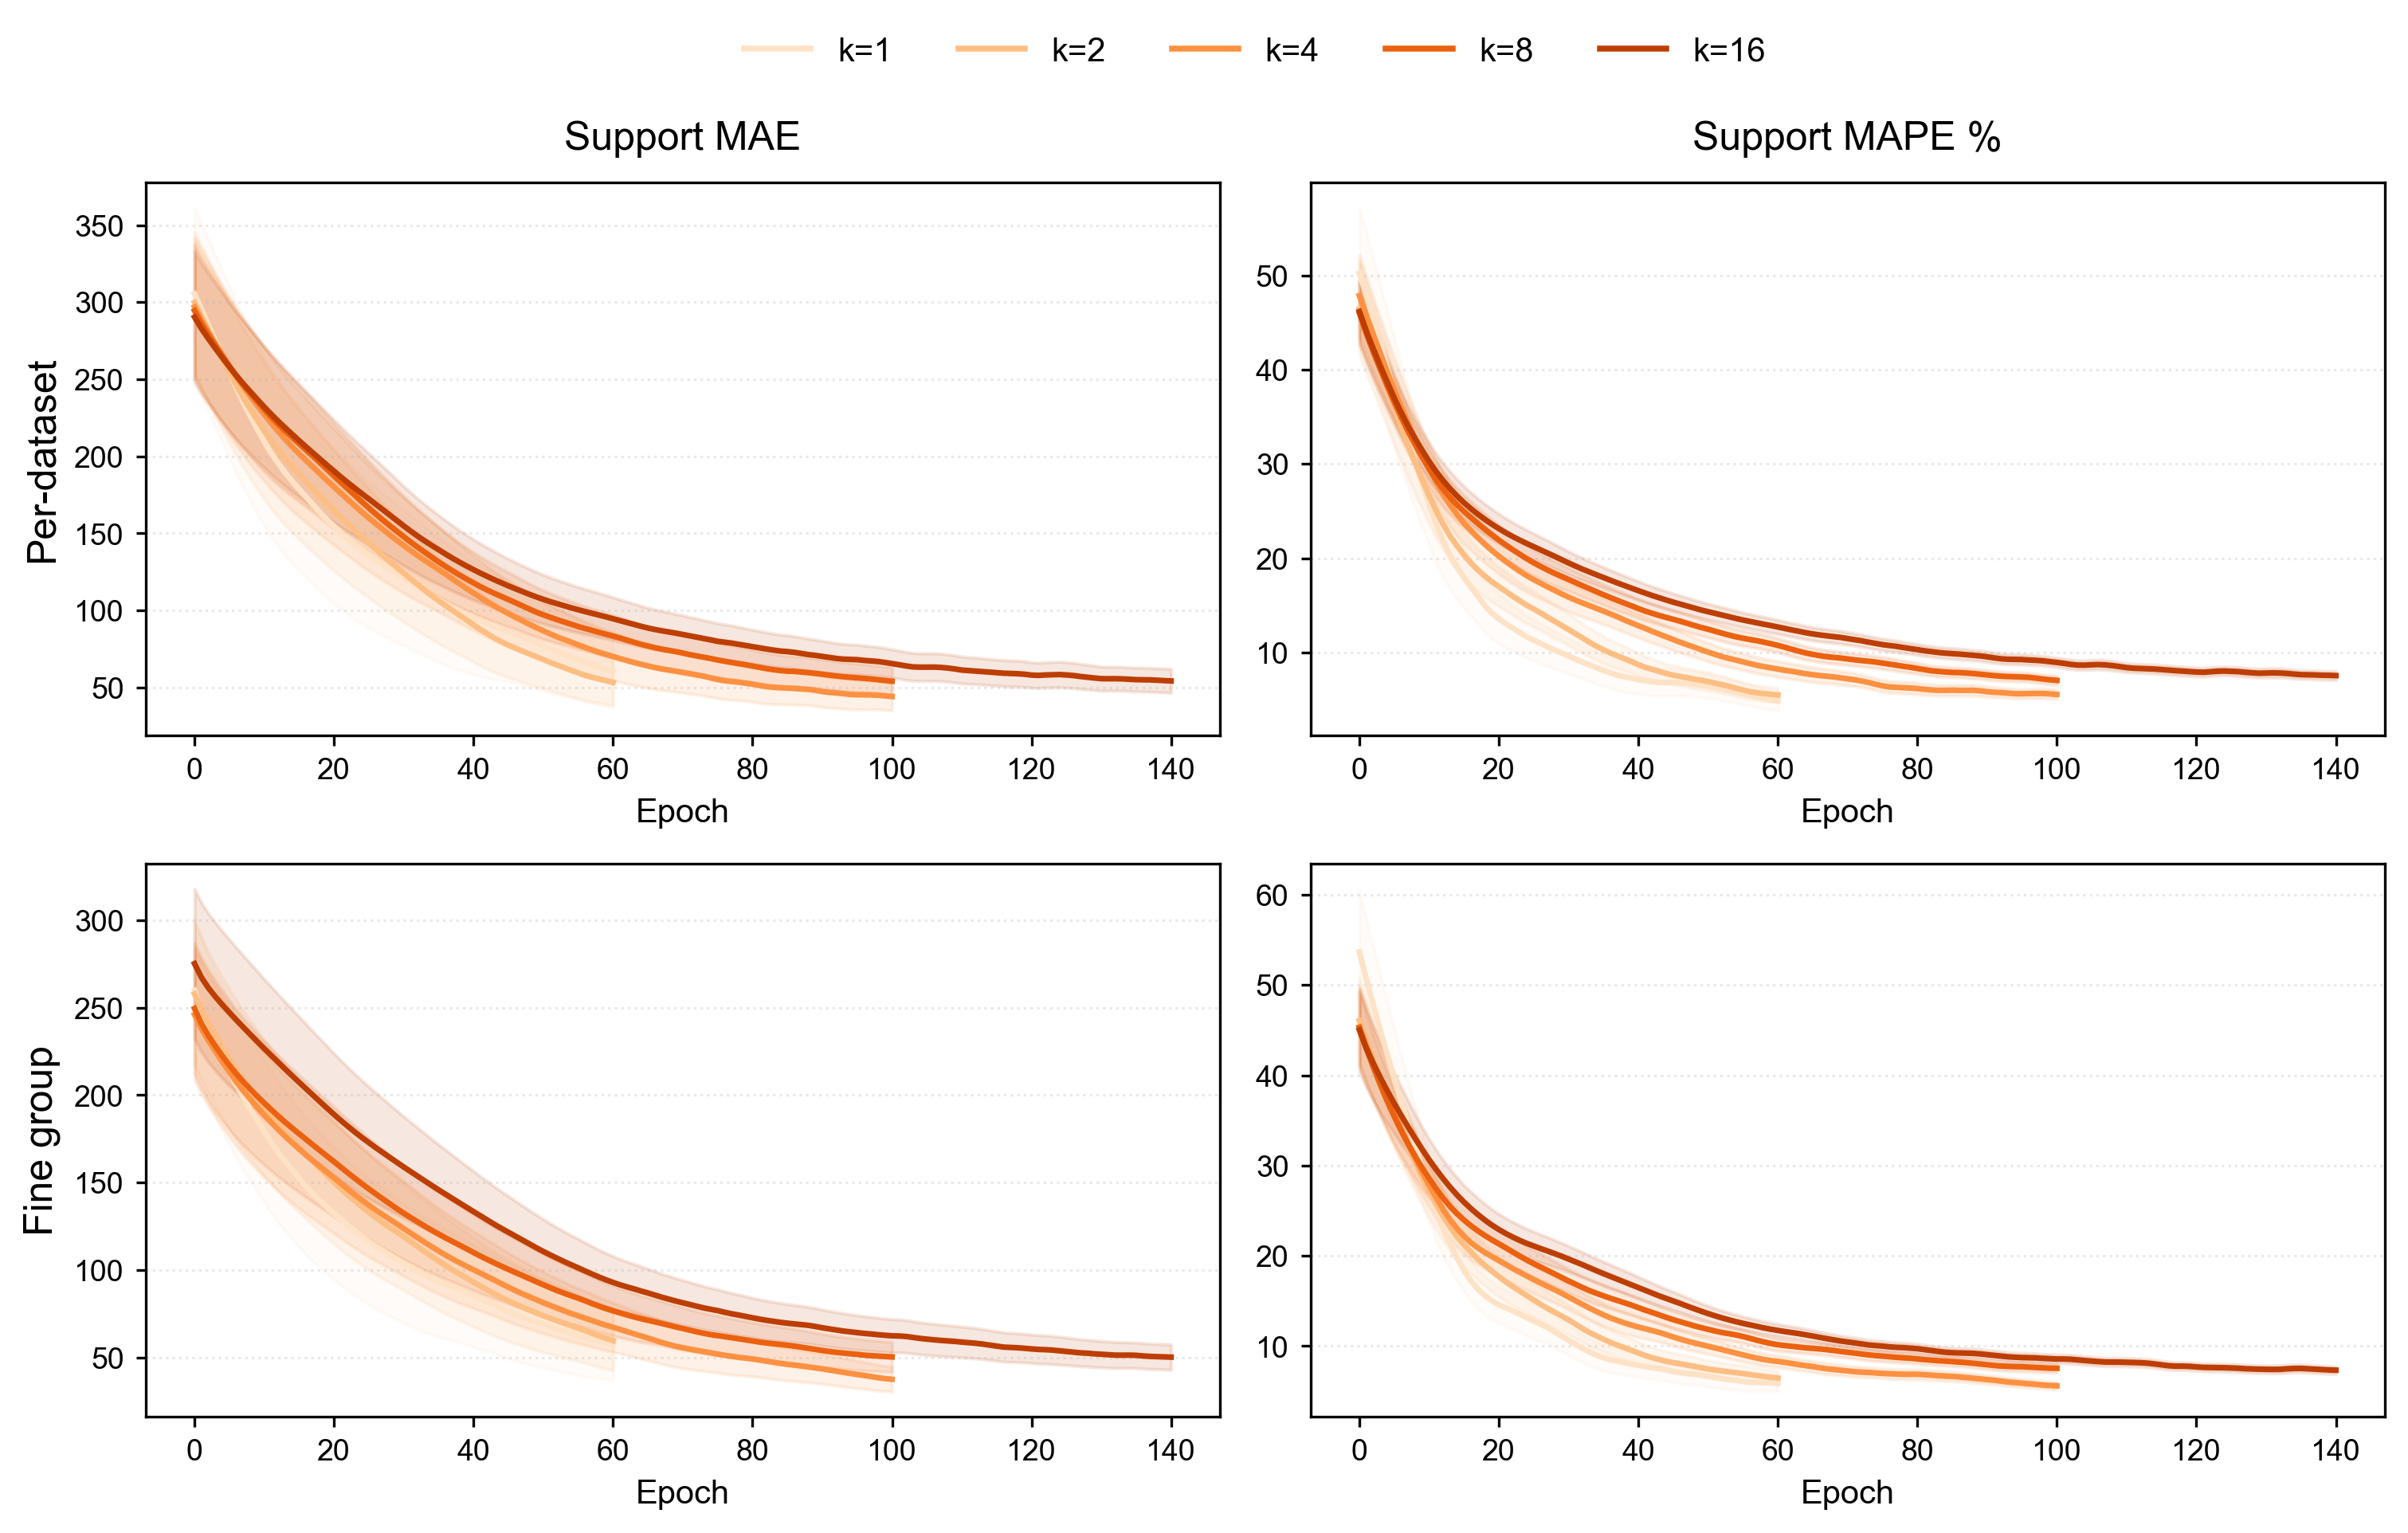

In [ ]:
plt.rcParams.update({
    "text.usetex": False,
    "font.family": "sans-serif",
    "font.sans-serif": ["Helvetica", "Arial", "DejaVu Sans"]
})

if ('transfer_diagnose_epoch_df' not in globals()) or transfer_diagnose_epoch_df.empty:
    print("Transfer diagnose support metric trajectory is empty.")
else:
    plot_df = transfer_diagnose_epoch_df.copy()
    grouping_order = [name for name in ["by dataset", "fine subgroup"] if name in plot_df["grouping_scheme"].astype(str).unique().tolist()]
    k_order = [k for k in [1, 2, 4, 8, 16] if k in pd.to_numeric(plot_df["k_shot"], errors="coerce").dropna().astype(int).unique().tolist()]
    metric_grid = [
        (("support_mae",), "Support MAE"),
        (("support_mape",), "Support MAPE %"),
    ]
    row_label_map = {"by dataset": "Per-dataset", "fine subgroup": "Fine group"}
    color_values = np.linspace(0.15, 0.82, max(len(k_order), 2))
    color_map = {int(k): plt.cm.Oranges(color_values[idx]) for idx, k in enumerate(k_order)}

    fig, axes = plt.subplots(2, 2, figsize=(10.6, 6.5), dpi=300, squeeze=False)
    for row_idx, grouping_scheme in enumerate(grouping_order):
        sub = plot_df.loc[plot_df["grouping_scheme"].eq(grouping_scheme)].copy()
        for col_idx, (metric_candidates, title_text) in enumerate(metric_grid):
            ax = axes[row_idx, col_idx]
            if sub.empty:
                ax.set_axis_off()
                continue
            metric_name = next((name for name in metric_candidates if name in sub.columns), None)
            if metric_name is None:
                ax.set_axis_off()
                continue
            for k_shot in k_order:
                k_sub = sub.loc[pd.to_numeric(sub["k_shot"], errors="coerce").eq(int(k_shot))].copy()
                if k_sub.empty:
                    continue
                grp = (
                    k_sub.groupby("epoch", dropna=False)[metric_name]
                    .agg(["mean", "std", "count"])
                    .reset_index()
                    .sort_values("epoch")
                )
                x = pd.to_numeric(grp["epoch"], errors="coerce").to_numpy(dtype=float)
                y = pd.to_numeric(grp["mean"], errors="coerce").to_numpy(dtype=float)
                std = pd.to_numeric(grp["std"], errors="coerce").fillna(0.0).to_numpy(dtype=float)
                count = pd.to_numeric(grp["count"], errors="coerce").fillna(0.0).to_numpy(dtype=float)
                ci95 = np.where(count > 1, 1.96 * std / np.sqrt(count), 0.0)
                ax.plot(x, y, color=color_map[int(k_shot)], linewidth=1.7, label=f"k={int(k_shot)}")
                ax.fill_between(x, y - ci95, y + ci95, color=color_map[int(k_shot)], alpha=0.12)
            if row_idx == 0:
                ax.set_title(title_text, fontsize=12, pad=10)
            ax.set_xlabel("Epoch", fontsize=10)
            if col_idx == 0:
                ax.set_ylabel(row_label_map.get(grouping_scheme, grouping_scheme.title()), fontsize=12)
            else:
                ax.set_ylabel("")
            ax.grid(axis="y", linestyle=":", linewidth=0.75, alpha=0.28)
            ax.tick_params(labelsize=9, length=3)

    handles = [plt.Line2D([0], [0], color=color_map[int(k)], linewidth=1.8) for k in k_order]
    labels = [f"k={int(k)}" for k in k_order]
    fig.legend(handles, labels, frameon=False, fontsize=10, loc="upper center", bbox_to_anchor=(0.52, 1.01), ncol=len(k_order))
    fig.tight_layout(rect=[0.02, 0.02, 0.98, 0.96])
    #plt.savefig(FIGURE_DIR / "S10-14.tiff", format="tiff", dpi=500, bbox_inches="tight")
    plt.show()


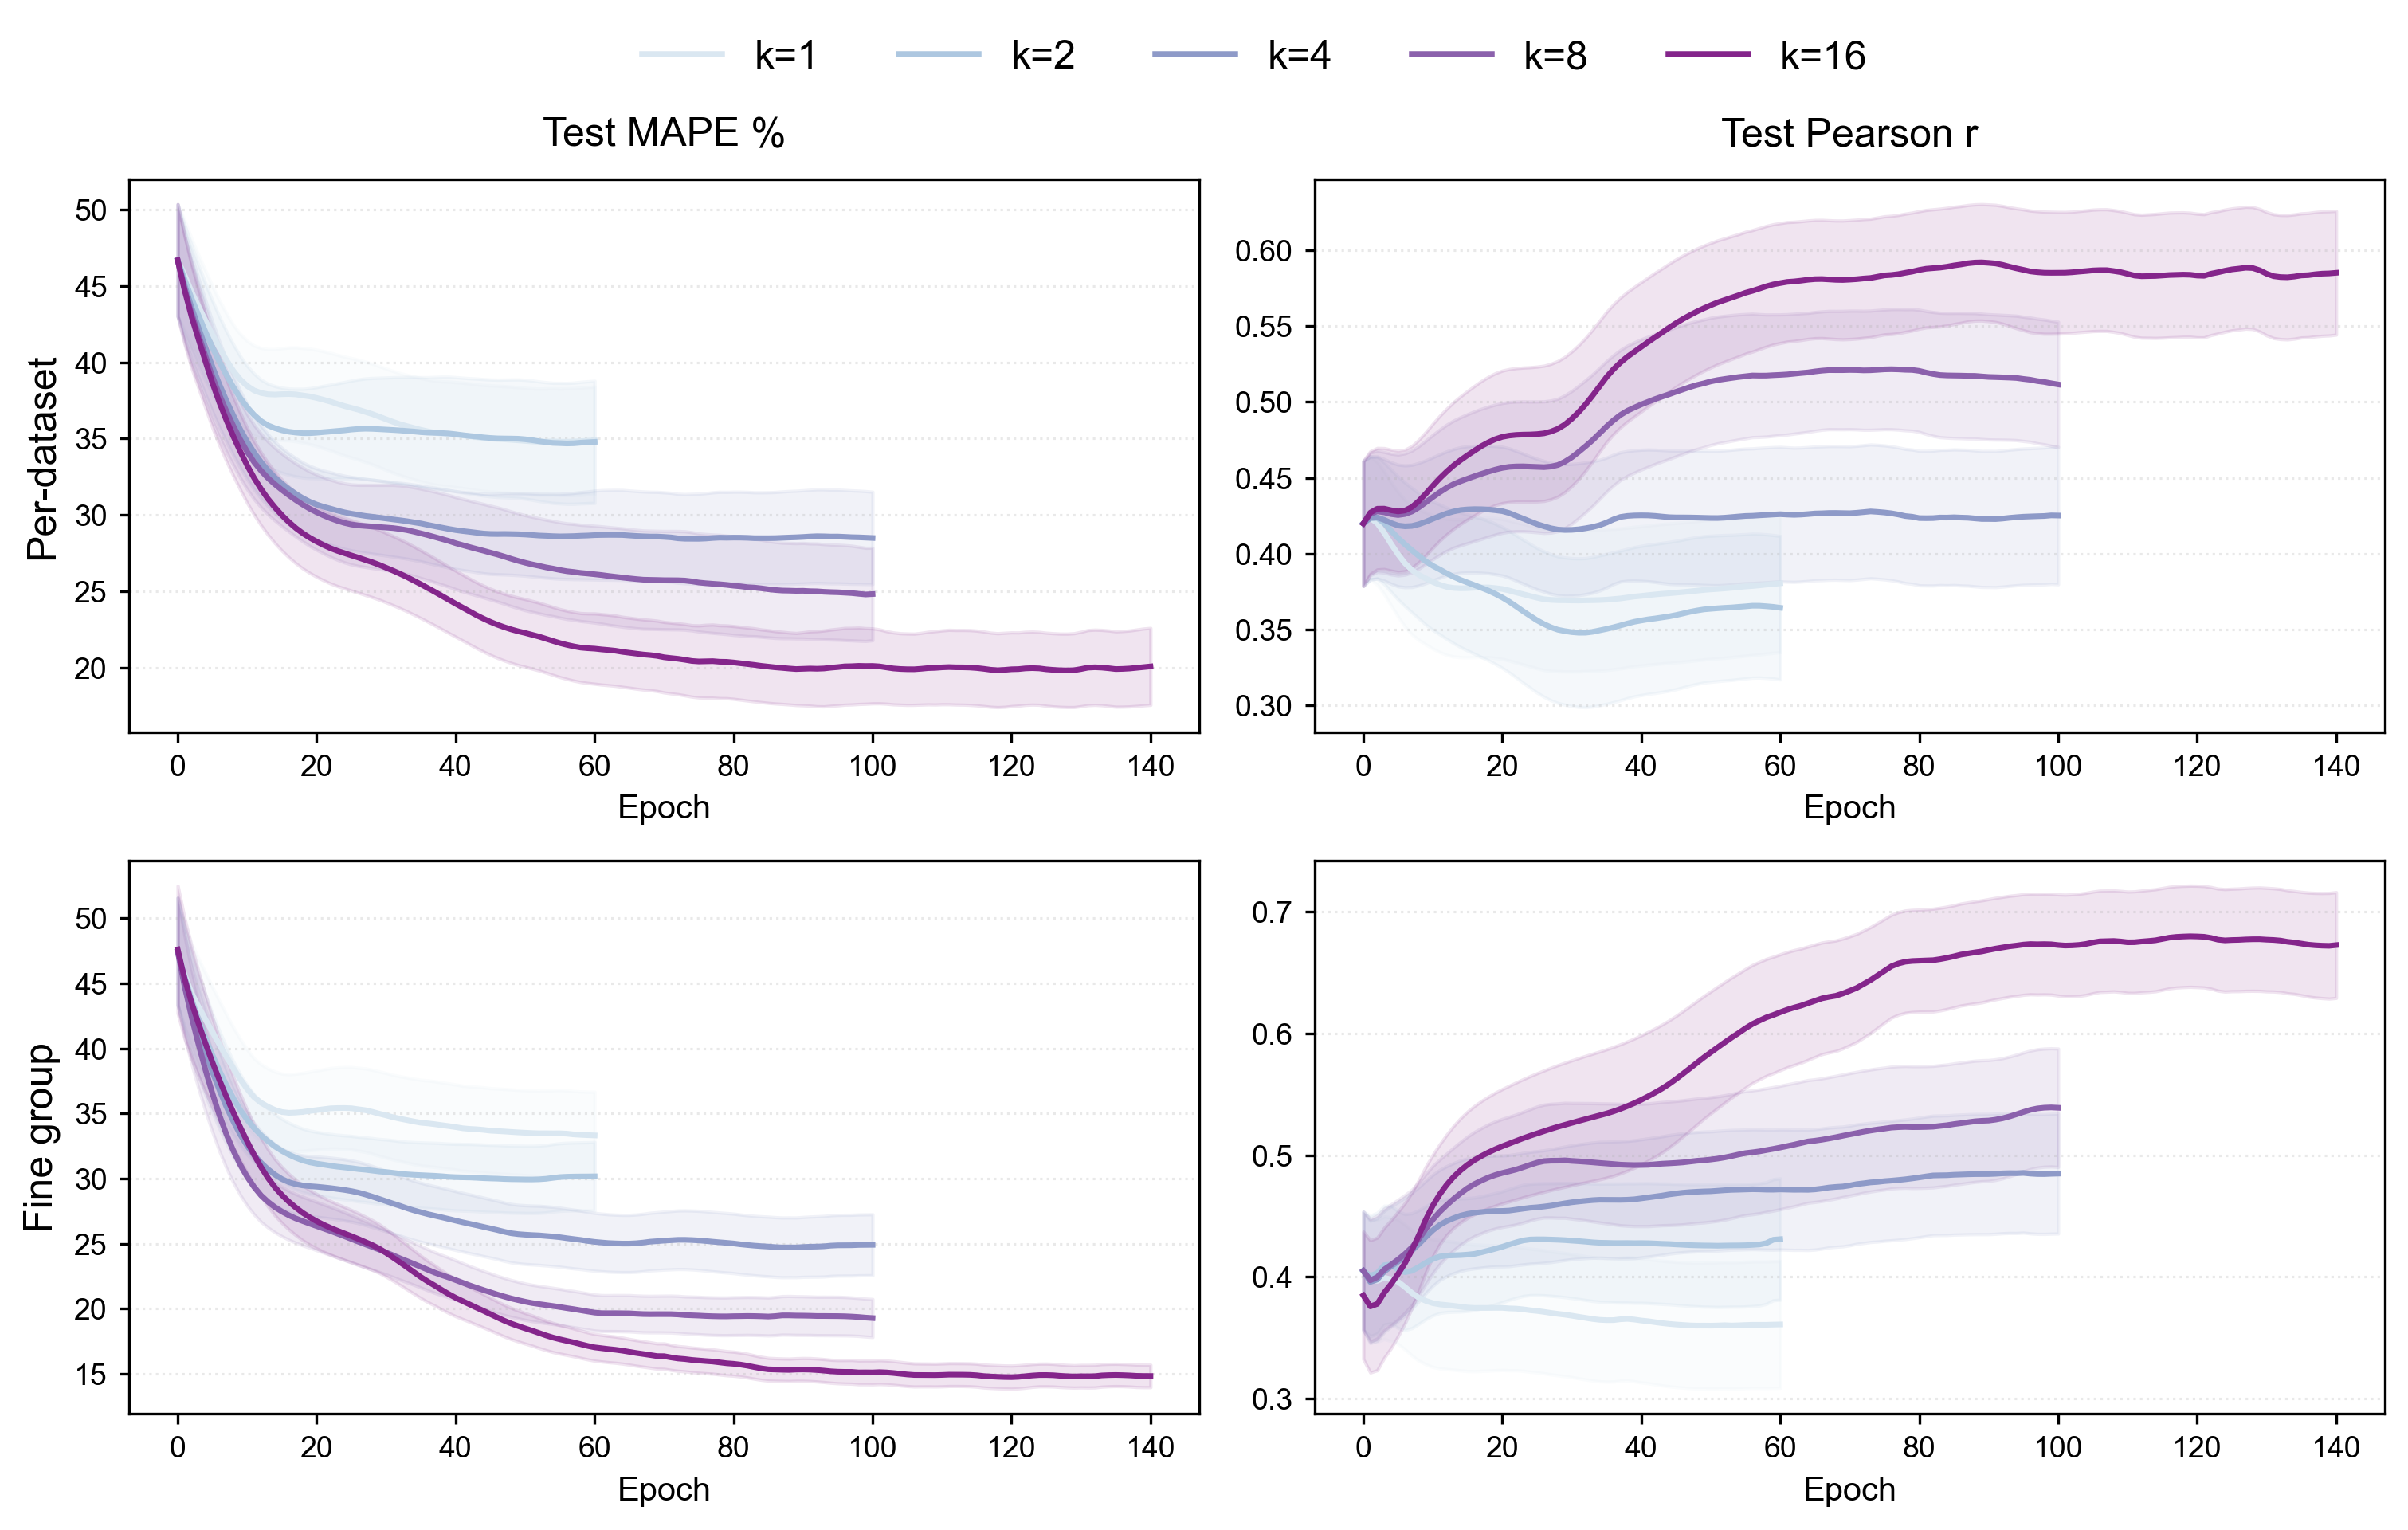

In [ ]:
plt.rcParams.update({
    "text.usetex": False,
    "font.family": "sans-serif",
    "font.sans-serif": ["Helvetica", "Arial", "DejaVu Sans"]
})

if ('transfer_diagnose_epoch_df' not in globals()) or transfer_diagnose_epoch_df.empty:
    print("Transfer diagnose test metric trajectory is empty.")
else:
    plot_df = transfer_diagnose_epoch_df.copy()
    grouping_order = [name for name in ["by dataset", "fine subgroup"] if name in plot_df["grouping_scheme"].astype(str).unique().tolist()]
    k_order = [k for k in [1, 2, 4, 8, 16] if k in pd.to_numeric(plot_df["k_shot"], errors="coerce").dropna().astype(int).unique().tolist()]
    metric_grid = [
        (("test_mape",), "Test MAPE %"),
        (("test_pearson_r", "test_pearson"), "Test Pearson r"),
    ]
    row_label_map = {"by dataset": "Per-dataset", "fine subgroup": "Fine group"}
    color_values = np.linspace(0.15, 0.82, max(len(k_order), 2))
    color_map = {int(k): plt.cm.BuPu(color_values[idx]) for idx, k in enumerate(k_order)}

    fig, axes = plt.subplots(2, 2, figsize=(10.6, 6.5), dpi=300, squeeze=False)
    for row_idx, grouping_scheme in enumerate(grouping_order):
        sub = plot_df.loc[plot_df["grouping_scheme"].eq(grouping_scheme)].copy()
        for col_idx, (metric_candidates, title_text) in enumerate(metric_grid):
            ax = axes[row_idx, col_idx]
            if sub.empty:
                ax.set_axis_off()
                continue
            metric_name = next((name for name in metric_candidates if name in sub.columns), None)
            if metric_name is None:
                ax.set_axis_off()
                continue
            for k_shot in k_order:
                k_sub = sub.loc[pd.to_numeric(sub["k_shot"], errors="coerce").eq(int(k_shot))].copy()
                if k_sub.empty:
                    continue
                grp = (
                    k_sub.groupby("epoch", dropna=False)[metric_name]
                    .agg(["mean", "std", "count"])
                    .reset_index()
                    .sort_values("epoch")
                )
                x = pd.to_numeric(grp["epoch"], errors="coerce").to_numpy(dtype=float)
                y = pd.to_numeric(grp["mean"], errors="coerce").to_numpy(dtype=float)
                std = pd.to_numeric(grp["std"], errors="coerce").fillna(0.0).to_numpy(dtype=float)
                count = pd.to_numeric(grp["count"], errors="coerce").fillna(0.0).to_numpy(dtype=float)
                ci95 = np.where(count > 1, 1.96 * std / np.sqrt(count), 0.0)
                ax.plot(x, y, color=color_map[int(k_shot)], linewidth=1.7, label=f"k={int(k_shot)}")
                ax.fill_between(x, y - ci95, y + ci95, color=color_map[int(k_shot)], alpha=0.12)
            if row_idx == 0:
                ax.set_title(title_text, fontsize=12, pad=10)
            ax.set_xlabel("Epoch", fontsize=10)
            if col_idx == 0:
                ax.set_ylabel(row_label_map.get(grouping_scheme, grouping_scheme.title()), fontsize=12)
            else:
                ax.set_ylabel("")
            if metric_name == "test_pearson":
                ax.set_ylim(0.0, 1.0)
            ax.grid(axis="y", linestyle=":", linewidth=0.75, alpha=0.28)
            ax.tick_params(labelsize=9, length=3)

    handles = [plt.Line2D([0], [0], color=color_map[int(k)], linewidth=1.8) for k in k_order]
    labels = [f"k={int(k)}" for k in k_order]
    fig.legend(handles, labels, frameon=False, fontsize=12, loc="upper center", bbox_to_anchor=(0.52, 1.01), ncol=len(k_order))
    fig.tight_layout(rect=[0.02, 0.02, 0.98, 0.96])
    #plt.savefig(FIGURE_DIR / "S10-15.tiff", format="tiff", dpi=500, bbox_inches="tight")
    plt.show()
